# Visualising inputs (strain + witness)

In [1]:
from pathlib import Path
import h5py
import numpy as np
import matplotlib.pyplot as plt
from gwpy.timeseries import TimeSeries

In [2]:
OUT_DIR = Path("../dataset/out")
SAMPLE_RATE = 4096 
EXAMPLE_INDEX = 2

CLASSES = ["background", "signal", "glitch"]
CHANNELS = ["strain", "witness"]
COLORS = {"strain": "#1f77b4", "witness": "#d62728"}

In [3]:
def load_example(cls, index=EXAMPLE_INDEX, out_dir=OUT_DIR, sample_rate=SAMPLE_RATE):
    path = Path(out_dir) / f"{cls}.h5"
    
    with h5py.File(path, "r") as f:
        sample = f["data"][index]  # (2, T)
        chan_names = [
            c.decode() if isinstance(c, (bytes, bytearray)) else str(c)
            for c in f.attrs["channels"]
        ]
    return {
        name: TimeSeries(
            sample[i].astype(float),
            sample_rate=sample_rate,
            name=f"{cls} — {name}",
        )
        for i, name in enumerate(chan_names)
    }


examples = {cls: load_example(cls) for cls in CLASSES}
print({cls: {ch: ts.shape for ch, ts in chans.items()} for cls, chans in examples.items()})

{'background': {'strain': (4096,), 'witness': (4096,)}, 'signal': {'strain': (4096,), 'witness': (4096,)}, 'glitch': {'strain': (4096,), 'witness': (4096,)}}


## 1. Time domain

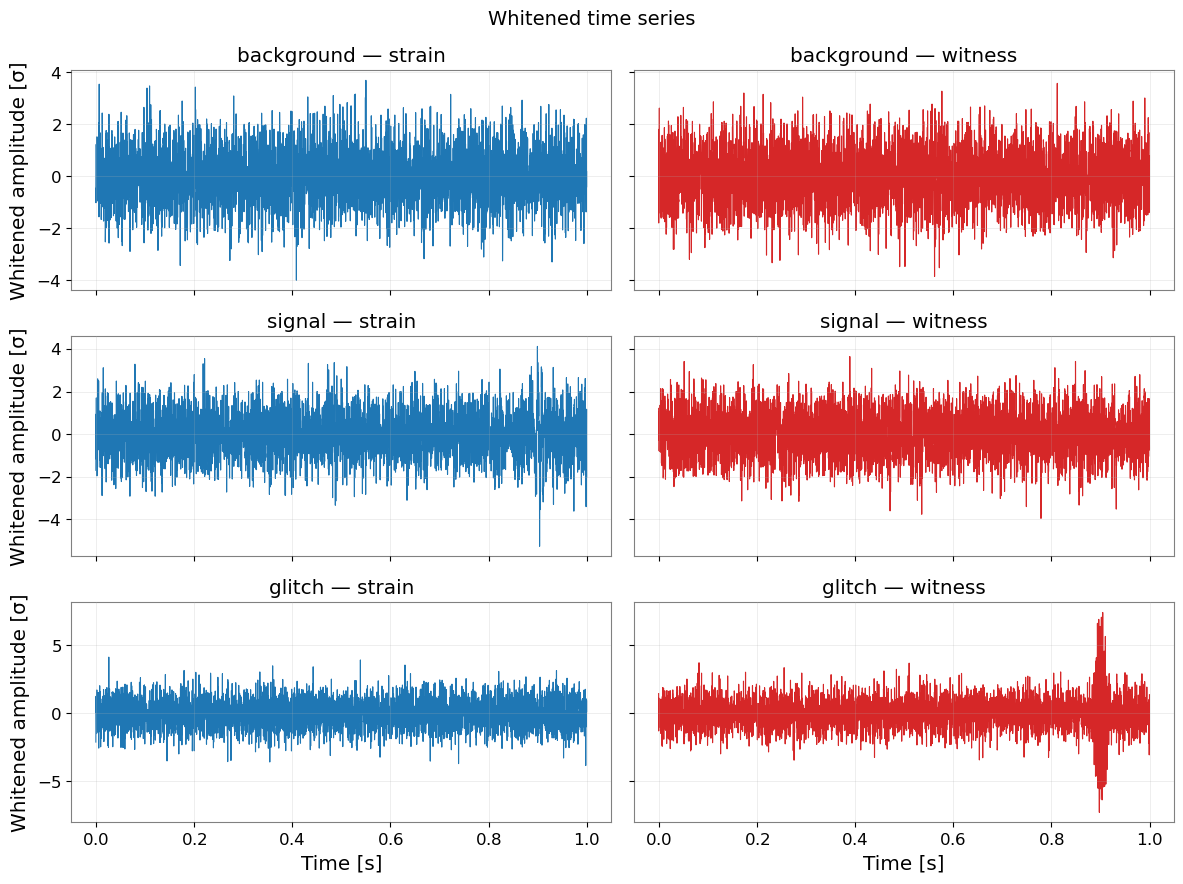

In [4]:
fig, axes = plt.subplots(
    len(CLASSES), len(CHANNELS), figsize=(12, 9), sharex=True, sharey="row"
)

for r, cls in enumerate(CLASSES):
    for c, ch in enumerate(CHANNELS):
        ts = examples[cls][ch]
        ax = axes[r, c]
        ax.plot(ts.times.value, ts.value, lw=0.8, color=COLORS[ch])
        ax.set_title(f"{cls} — {ch}")
        ax.grid(True, alpha=0.3)
        if r == len(CLASSES) - 1:
            ax.set_xlabel("Time [s]")
        if c == 0:
            ax.set_ylabel("Whitened amplitude [σ]")

fig.suptitle("Whitened time series", fontsize=14)
fig.tight_layout()
plt.show()

## 2. Frequency domain

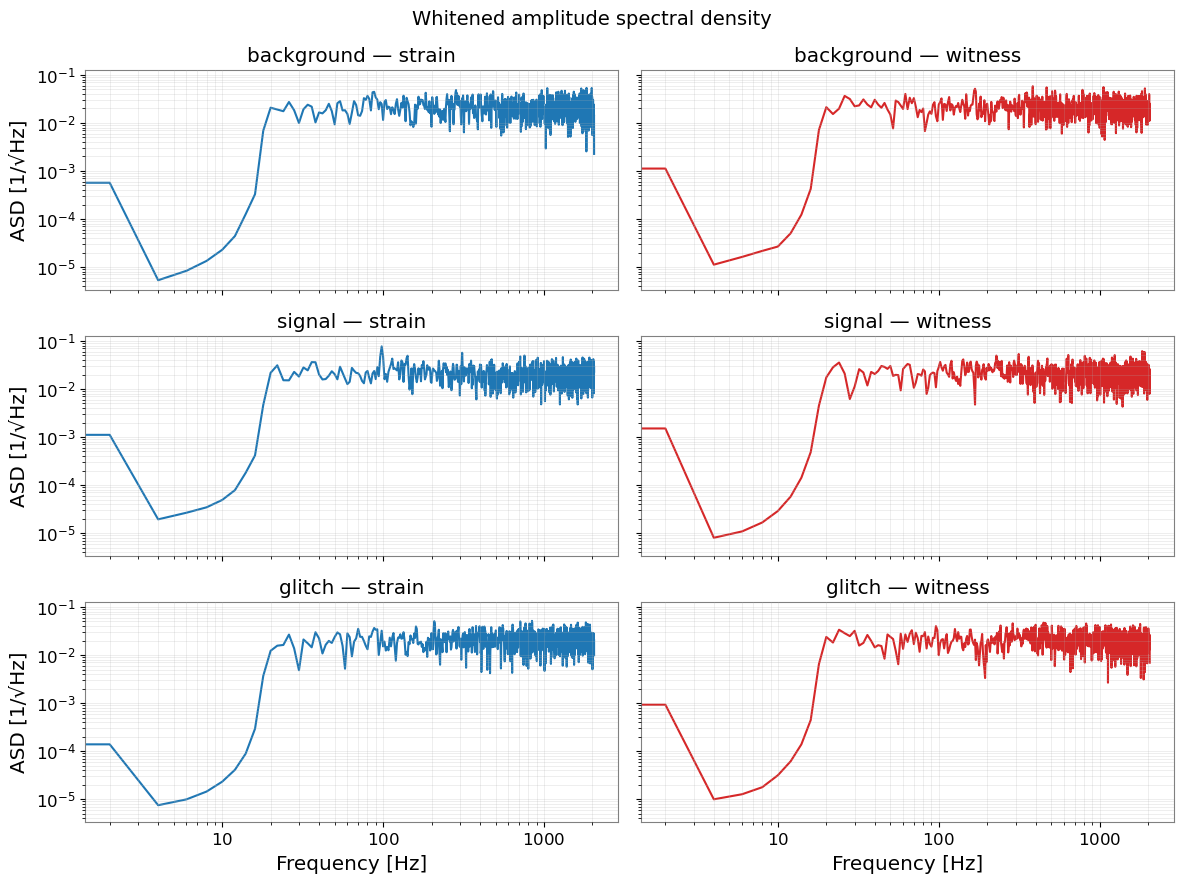

In [5]:
# Short segments (1 s by default) -> use a sub-second FFT length so we still average a few
# segments for a smoother estimate.
duration = examples[CLASSES[0]][CHANNELS[0]].duration.value
fftlength = min(0.5, duration)
overlap = fftlength / 2

fig, axes = plt.subplots(
    len(CLASSES), len(CHANNELS), figsize=(12, 9), sharex=True, sharey=True
)

for r, cls in enumerate(CLASSES):
    for c, ch in enumerate(CHANNELS):
        ts = examples[cls][ch]
        asd = ts.asd(fftlength=fftlength, overlap=overlap)
        ax = axes[r, c]
        ax.loglog(asd.frequencies.value, asd.value, color=COLORS[ch])
        ax.set_title(f"{cls} — {ch}")
        ax.grid(True, which="both", alpha=0.3)
        if r == len(CLASSES) - 1:
            ax.set_xlabel("Frequency [Hz]")
        if c == 0:
            ax.set_ylabel("ASD [1/√Hz]")

fig.suptitle("Whitened amplitude spectral density", fontsize=14)
fig.tight_layout()
plt.show()

## 3. Q transform

/n/holystore01/LABS/iaifi_lab/Users/creissel/miniforge/envs/ssm/lib/python3.10/site-packages/gwpy/signal/qtransform.py:124: UserWarning: upper frequency of 2048.00 is too high for the given Q range, resetting to 1291.05
  warnings.warn('upper frequency of %.2f is too high for the given '
/n/holystore01/LABS/iaifi_lab/Users/creissel/miniforge/envs/ssm/lib/python3.10/site-packages/gwpy/signal/qtransform.py:124: UserWarning: upper frequency of 2048.00 is too high for the given Q range, resetting to 1291.05
  warnings.warn('upper frequency of %.2f is too high for the given '


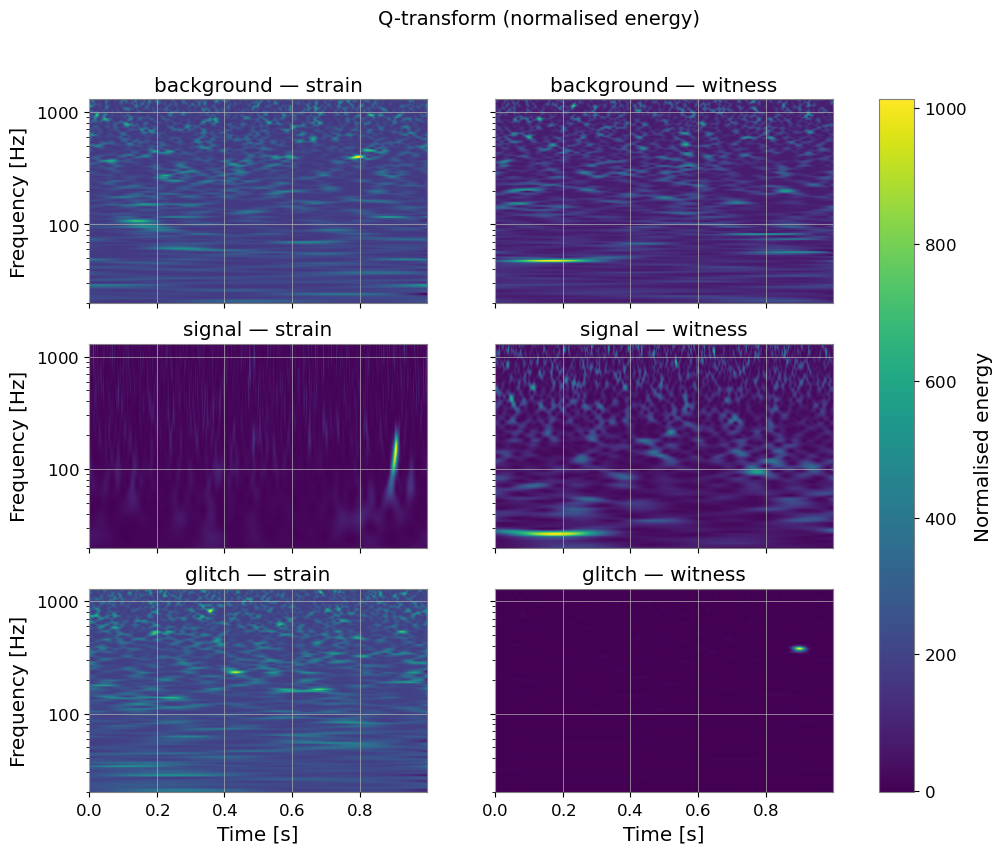

In [6]:
fig, axes = plt.subplots(
    len(CLASSES), len(CHANNELS), figsize=(12, 9), sharex=True, sharey=True
)

meshes = []
for r, cls in enumerate(CLASSES):
    for c, ch in enumerate(CHANNELS):
        ts = examples[cls][ch]
        # frange capped at Nyquist; qrange kept modest for short (1 s) segments
        qgram = ts.q_transform(
            whiten=False,
            frange=(20, SAMPLE_RATE / 2),
            qrange=(4, 64),
            logf=True,
        )
        ax = axes[r, c]
        mesh = ax.pcolormesh(
            qgram.times.value - qgram.times.value[0],
            qgram.frequencies.value,
            qgram.value.T,
            shading="auto",
            cmap="viridis",
        )
        meshes.append(mesh)
        ax.set_yscale("log")
        ax.set_title(f"{cls} — {ch}")
        if r == len(CLASSES) - 1:
            ax.set_xlabel("Time [s]")
        if c == 0:
            ax.set_ylabel("Frequency [Hz]")

fig.suptitle("Q-transform (normalised energy)", fontsize=14)
fig.colorbar(meshes[-1], ax=axes, label="Normalised energy")
plt.show()

In [7]:
import h5py, numpy as np

with h5py.File(OUT_DIR / "glitch.h5", "r") as f:
    d = f["data"][1]                 # (2, T) -> [strain, witness]
    ss = f["strain_snr"][1]
    ws = f["witness_snr"][1]

strain, witness = d[0], d[1]
print("strain  : std=%.3g  min=%.3g  max=%.3g  n_nan=%d  all_zero=%s"
      % (strain.std(), strain.min(), strain.max(), np.isnan(strain).sum(), np.allclose(strain, 0)))
print("witness : std=%.3g  min=%.3g  max=%.3g  n_nan=%d"
      % (witness.std(), witness.min(), witness.max(), np.isnan(witness).sum()))
print("strain_snr=%.2f  witness_snr=%.2f" % (ss, ws))

strain  : std=0  min=0  max=0  n_nan=0  all_zero=True
witness : std=1.07  min=-4.02  max=4.04  n_nan=0
strain_snr=15.75  witness_snr=15.19
